In [1]:
from swemnics.problems import SlopedBeachProblem
from swemnics import solvers as Solvers
from mpi4py import MPI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dolfinx import fem as fe
import pickle
from tqdm import tqdm

import pandas as pd
import seaborn as sns
from typing import Callable, Dict, List, Tuple, Any, Union

from plotting import plot_simulation_results, create_comparison_figure
from fourd_var import run_assimilation
from dca_utils import*

sns.set_palette("bright")
plt.style.use("mystyle1.mplstyle")


In [32]:
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

problem_params = {
    'dt': 600,
    't': 0,
    't_final': 7*24*60*60,
    'num_steps': int(np.ceil((7*24*60*60)/600)),
    'num_windows': 4,
    'fric_law': 'mannings',    #friction law either quadratic or linear
    'sol_var': 'h'             #solution variable either h or hu
}

solver_params = {"rtol": 1e-5,
          "atol": 1e-6,
          "max_it":10,
          "relaxation_parameter":1.0,
          "ksp_type": "gmres",
          "pc_type": "ilu",
          "ksp_ErrorIfNotConverged": False
          }#,"pc_factor_mat_solver_type":"mumps"}



In [33]:
size 

1

In [3]:
assert problem_params['num_steps'] == int(np.ceil(problem_params['t_final']/problem_params['dt']))
true_signal, prob, stations, state_coords = get_true_signal(problem_params,'sloped_beach', solver_params,4)

Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux


In [4]:

def build_observation_matrix(prob, V, obs_time_freq=2):
    num_cells = len(prob.mesh.geometry.dofmap)
    all_cells = np.arange(num_cells)
    obs_space_idx = np.arange(0, num_cells, obs_time_freq) # select every obs_time_freq-th cell for observation
    station_cells = all_cells[obs_space_idx]  # select cells for observation

    # Create observation matrix
    H = np.zeros((len(station_cells), V.dofmap.index_map.size_local))

    # pick subset of cells for the stations 
    station_coords = []

    # collapse the function space to get the coordinates of the dofs
    # in the cells that are selected for observation
    V_collapsed, indices_into_V = V.sub(0).collapse()   
    collapsed_dof_coords = V_collapsed.tabulate_dof_coordinates()
    indices_into_V = np.array(indices_into_V)

    for station, i in enumerate(station_cells):
        coords_for_cell = collapsed_dof_coords[V_collapsed.dofmap.cell_dofs(i)]
        dofs_in_orig_V = indices_into_V[V_collapsed.dofmap.cell_dofs(i)]
        H[station, dofs_in_orig_V] = 1/3 
        station_coord = 1/3 * (coords_for_cell.sum(axis=0))
        station_coords.append(station_coord)
        # print(f"Station {station} at {station_coord} corresponds to cell {i} with dofs {dofs_in_orig_V}")
    
    print(f"Total cells in mesh: {num_cells}")
    print(f"obs_time_freq: {obs_time_freq}")
    print(f"obs_space_idx: {obs_space_idx}")
    print(f"station_cells: {station_cells}")
    print(f"Number of observation stations: {len(station_cells)}")
    
    
    return H, np.array(station_coords), obs_space_idx


def generate_observations(true_states, H, obs_time_idx, obs_std=0.1):
    # Extract only the states at the observation indices
    true_states = np.array(true_states)  # Ensure true_states is a numpy array
    observed_states = true_states[obs_time_idx]  # shape: (n_obs, state_dim)
    
    # Apply observation operator to all observed states at once
    y_n = observed_states @ H.T  # shape: (n_obs, obs_dim)

    # Add Gaussian noise
    noise = obs_std * np.random.randn(*y_n.shape)
    y_obs = y_n + noise

    return y_obs

def setup_observation_indices(window_size, obs_frequency, total_steps):
    """Setup observation indices for windows"""
    obs_indices_per_window = np.arange(0, window_size, obs_frequency)
    obs_indices = np.arange(0, total_steps - 1, obs_frequency)
    return obs_indices_per_window, obs_indices

In [5]:

obs_std=0.4
obs_time_freq = 2
obs_space_freq = 2
total_steps = int((problem_params['t_final']/problem_params['dt']) + 1)
problem_params['num_steps'] = int(np.ceil((7*24*60*60)/600)/problem_params['num_windows']) # Size of each assimilation window
obs_per_window = problem_params['num_steps'] // obs_time_freq

H, stations, obs_spatial_indices = build_observation_matrix(prob, true_signal.V, obs_space_freq)
obs_indices_per_window, obs_time_indices = setup_observation_indices(problem_params['num_steps'], obs_time_freq, total_steps)

# Create synthetic observations
y_obs = generate_observations(true_signal.saved_states, H, obs_time_indices, obs_std)

print(f"\n Total Steps: {total_steps}\n"
      f"Total Assimilation Windows: {problem_params['num_windows']}\n"
      f"Steps per Window: {problem_params['num_steps']}\n"
      f"Obs Frequency: {obs_time_freq}\n"
      f"Total Obs: {obs_per_window * problem_params['num_windows']}\n"
      f"Number Stations: {stations.shape[0]}\n"
      f"Obs per Window: {obs_per_window}\n")



# Generate Background,Observation, and Predicted Error Covariance Matrices
state_dim = true_signal.saved_adjoints[0].shape[0]
obs_dim = stations.shape[0]

# Observation Covariance 
R = np.eye(obs_dim) * (obs_std**2)

inflation_factor=2.0
B = inflation_factor*np.eye(state_dim) 

# Predicted Covariance
L = H @ B @ H.T 

# Get Inverse Covariance matrices
R_inv = np.linalg.inv(R)
B_inv = np.linalg.inv(B) 
L_inv = np.linalg.inv(L)

covs = {"B_inv": B_inv, "R_inv": R_inv, "L_inv": L_inv}

hb = 5.0 / 13800 * (13800 - stations[:, 0])

print(f"\nState Dimension: {state_dim}\n"
      f"Observation Dimension: {obs_dim}\n"
      f"Background Covariance Matrix Shape B: {B.shape}\n"
      f"Observation Covariance Matrix Shape R: {R.shape}\n"
      f"Predicted Error Covariance Matrix shape L: {L.shape}\n"
      f"Observation Matrix Shape H: {H.shape}\n",
      f"y_obs shape: {y_obs.shape}\n",
      f"Stations shape: {stations.shape}\n",
)


Total cells in mesh: 144
obs_time_freq: 2
obs_space_idx: [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142]
station_cells: [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142]
Number of observation stations: 72

 Total Steps: 1009
Total Assimilation Windows: 4
Steps per Window: 252
Obs Frequency: 2
Total Obs: 504
Number Stations: 72
Obs per Window: 126


State Dimension: 1296
Observation Dimension: 72
Background Covariance Matrix Shape B: (1296, 1296)
Observation Covariance Matrix Shape R: (72, 72)
Predicted Erro

In [6]:
print(f"max:{H.max()}, "
      f"min: {H.min()}, "
      f"2-norm: {np.linalg.norm(H, ord=2)}, "
      f"cond #: {np.linalg.cond(H)}, "
      f"rank: {np.linalg.matrix_rank(H)}")

max:0.3333333333333333, min: 0.0, 2-norm: 0.5773502691896257, cond #: 1.0, rank: 72


In [7]:
bayes_analysis = run_assimilation(
                                  problem_params,
                                  solver_params,
                                  stations,
                                  y_obs,
                                  obs_per_window,
                                  obs_spatial_indices,
                                  obs_time_indices,
                                  H,
                                  covs,
                                  hb,
                                'sloped_beach',
                                cost_function_type='bayes'
                             )

true_states = np.array(true_signal.saved_states)
Hu_true = (H @ true_states.T)  
pred = bayes_analysis[1:,:,0] + hb
bayes_height_misfit_rmse = np.sqrt(np.mean((Hu_true - pred.T) ** 2))
print(f"Bayes Analysis Height RMSE: {bayes_height_misfit_rmse}")

Processing windows:   0%|          | 0/4 [00:00<?, ?window/s]

Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux
Solver Time 1: 0
Background shape: (252, 1296)
Q_zb shape: (72, 126)
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
Iteration 1: Cost = 4575.044204
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
Iteration 2: Cost = 4575.044178

Optimization completed:
  Success: True
  Status: 0
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Final cost: 4.575044e+03
  Iterations: 2
  Function evaluations: 4
  Gradient norm at solution: 1.561207e-06

--------------------------------------------

Processing windows:  25%|██▌       | 1/4 [01:02<03:08, 62.88s/window]

/////////////////////////////////////// Window 1 Completed ////////////////////////////////////////////////// 


Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux
Solver Time 1: 151200
Background shape: (252, 1296)
Q_zb shape: (72, 126)
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
Iteration 1: Cost = 4483.019629

Optimization completed:
  Success: True
  Status: 0
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Final cost: 4.483019e+03
  Iterations: 1
  Function evaluations: 3
  Gradient norm at solution: 1.425606e-05

------------------------------------------------------------

State comparison (subsampled):
  Initial state

Processing windows:  50%|█████     | 2/4 [02:15<02:16, 68.42s/window]

/////////////////////////////////////// Window 2 Completed ////////////////////////////////////////////////// 


Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux
Solver Time 1: 302400
Background shape: (252, 1296)
Q_zb shape: (72, 126)
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
Iteration 1: Cost = 4611.208385
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Ra

Processing windows:  75%|███████▌  | 3/4 [08:16<03:22, 202.16s/window]

/////////////////////////////////////// Window 3 Completed ////////////////////////////////////////////////// 


Location of shoreline: 13800
Fully conservative flux
Fully conservative flux
WD nonspherical

Fully conservative flux
Solver Time 1: 453600
Background shape: (252, 1296)
Q_zb shape: (72, 126)
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
[Rank 0] Reached checkpoint F
[Rank 0] Reached checkpoint E
[Rank 0] Reached checkpoint D
Iteration 1: Cost = 4496.393278

Optimization completed:
  Success: True
  Status: 0
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Final cost: 4.496394e+03
  Iterations: 1
  Function evaluations: 3
  Gradient norm at solution: 1.426899e-05

------------------------------------------------------------

State comparison (subsampled):
  Initial state

Processing windows: 100%|██████████| 4/4 [09:27<00:00, 141.89s/window]

/////////////////////////////////////// Window 4 Completed ////////////////////////////////////////////////// 


Bayes Analysis Height RMSE: 0.0021624410366878335


In [11]:
np.savez_compressed('sloped_beach_4dvar_results.npz',
                    true_states=true_states,
                    y_obs=y_obs,
                    stations=stations,
                    bayes_analysis=bayes_analysis,
             )

In [12]:
# load the saved results
with np.load('sloped_beach_4dvar_results.npz') as data:
    true_states = data['true_states']
    y_obs = data['y_obs']
    stations = data['stations']
    bayes_analysis = data['bayes_analysis']

In [15]:
true_states.shape, bayes_analysis.shape

((1008, 1296), (1009, 72, 3))

In [ ]:
# dci_analysis = run_assimilation(
#                                   problem_params,
#                                   solver_params,
#                                   stations,
#                                   y_obs,
#                                   obs_per_window,
#                                   obs_spatial_indices,
#                                   obs_time_indices,
#                                   H,
#                                   covs,
#                                   hb,
#                                 'sloped_beach',
#                                 cost_function_type='dci'
#                              )

# true_states = np.array(true_signal.saved_states)
# Hu_true = (H @ true_states.T)  
# pred = dci_analysis[1:,:,0] + hb
# dci_height_misfit_rmse = np.sqrt(np.mean((Hu_true - pred.T) ** 2))
# print(f"DCI Analysis Height RMSE: {dci_height_misfit_rmse}")

In [ ]:
#DCI Analysis Height RMSE: 0.0022231062237823423

In [ ]:
true_signal.saved_states[0].shape, H.shape, y_obs.shape

In [ ]:
# save true_states array and observations


array([[ 4.16691911e-01,  1.79823199e-05,  1.81228103e-05, ...,
         8.78748756e-07,  1.23938042e-03, -1.59704030e-06],
       [ 4.16888311e-01,  1.67618802e-04,  1.69335511e-04, ...,
         1.18497059e-06,  5.20062462e-03, -2.32540328e-06],
       [ 4.17329819e-01,  5.10256280e-04,  5.15769522e-04, ...,
         1.44589906e-06,  1.17799526e-02, -2.94978342e-06],
       ...,
       [-8.59030876e-01, -1.26824810e+00, -1.27031965e+00, ...,
        -2.15901192e-05,  6.56800205e-01,  4.87313198e-05],
       [-8.48032576e-01, -1.27762106e+00, -1.28056623e+00, ...,
        -1.91349399e-05,  6.77161656e-01,  4.40598528e-05],
       [-8.17298116e-01, -1.26424185e+00, -1.26813925e+00, ...,
        -1.62472836e-05,  6.93383076e-01,  3.86898730e-05]],
      shape=(1008, 1296))

In [ ]:
# dci_wme_analysis = run_assimilation(
#                                   problem_params,
#                                   solver_params,
#                                   stations,
#                                   y_obs,
#                                   obs_per_window,
#                                   obs_spatial_indices,
#                                   obs_time_indices,
#                                   H,
#                                   covs,
#                                   hb,
#                                 'sloped_beach',
#                                 cost_function_type='dci_wme'
#                              )

# true_states = np.array(true_signal.saved_states)
# Hu_true = (H @ true_states.T)  
# pred = dci_wme_analysis[1:,:,0] + hb
# dci_wme_height_misfit_rmse = np.sqrt(np.mean((Hu_true - pred.T) ** 2))
# print(f"DCI Analysis Height RMSE: {dci_wme_height_misfit_rmse}")

In [ ]:
true_states.shape

In [ ]:
Hu_true = (H @ true_states.T)  
pred = dci_wme_analysis[1:,:,1] 
dci_wme_height_misfit_rmse = np.sqrt(np.mean((Hu_true - pred.T) ** 2))
print(f"DCI Analysis Height RMSE: {dci_wme_height_misfit_rmse}")

In [ ]:
plot_params = {
    "lines.linewidth": 8,
    "lines.markersize": 10,
    'lines.markeredgecolor': 'black',
    "legend.fontsize": 45,
    "legend.frameon": False,
    "xtick.labelsize": 45,
    "ytick.labelsize": 45,
    "axes.labelsize": 45,
    "axes.labelpad": 10,
    "axes.titlesize": 45,
    "figure.figsize": (44, 16),
}

station_idx = 10
with plt.rc_context(plot_params):
        plt.plot(Hu_true[station_idx], linestyle="solid", label='True')
        plt.plot(pred.T[station_idx], linestyle="dashed", label='Predicted')
        plt.legend(loc='upper left')
        plt.xlabel('Time Step')
        plt.ylabel('Water Height (m)')
        plt.title(f'Station {station_idx} Water Height Over Time')
        plt.show()

In [39]:
def plot_comparison_matplotlib(msh, V, u_array_list, component=0, titles=None, stations=None, cmap='viridis'):
    """
    Matplotlib-based side-by-side comparison of multiple mixed-space solutions from raw arrays.

    Parameters:
    - msh: dolfinx.mesh.Mesh
    - V: dolfinx.fem.FunctionSpace (mixed space)
    - u_array_list: list of np.ndarray (raw .x.array[:] values)
    - component: int, index of the subcomponent to plot
    - titles: list of titles for each subplot
    - stations: optional Nx3 or Nx2 array of station coordinates
    - cmap: str, matplotlib colormap
    """
    n_plots = len(u_array_list)
    coords = msh.geometry.x[:, :2]

    # Mesh topology for triangulation
    tdim = msh.topology.dim
    msh.topology.create_connectivity(tdim, 0)
    cells = msh.topology.connectivity(tdim, 0).array.reshape(-1, 3)
    triang = Triangulation(coords[:, 0], coords[:, 1], cells)

    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), constrained_layout=True)
    if n_plots == 1:
        axes = [axes]

    for i, (u_array, ax) in enumerate(zip(u_array_list, axes)):
        V_sub = V.sub(component)
        V_sub_c, sub_map = V_sub.collapse()

        u_sub = Function(V_sub_c)
        u_sub.x.array[:] = u_array[sub_map]

        dof_coords = V_sub_c.tabulate_dof_coordinates()[:, :2]
        dof_to_vertex_map = np.array([np.argmin(np.linalg.norm(dof_coords - x, axis=1)) for x in coords])
        values_at_vertices = u_sub.x.array[dof_to_vertex_map]

        tpc = ax.tripcolor(triang, values_at_vertices, shading='gouraud', cmap=cmap)
        ax.triplot(triang, color='k', linewidth=0.3, alpha=0.5)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

        if titles and i < len(titles):
            ax.set_title(titles[i])
        else:
            ax.set_title(f"Solution {i + 1}")

        if stations is not None:
            stations = np.asarray(stations)
            if stations.shape[1] == 3:
                stations = stations[:, :2]
            ax.plot(stations[:, 0], stations[:, 1], 'ro', markersize=5)

    cbar = fig.colorbar(tpc, ax=axes, orientation='vertical', shrink=0.9)
    cbar.set_label("Function Value")

    plt.show()




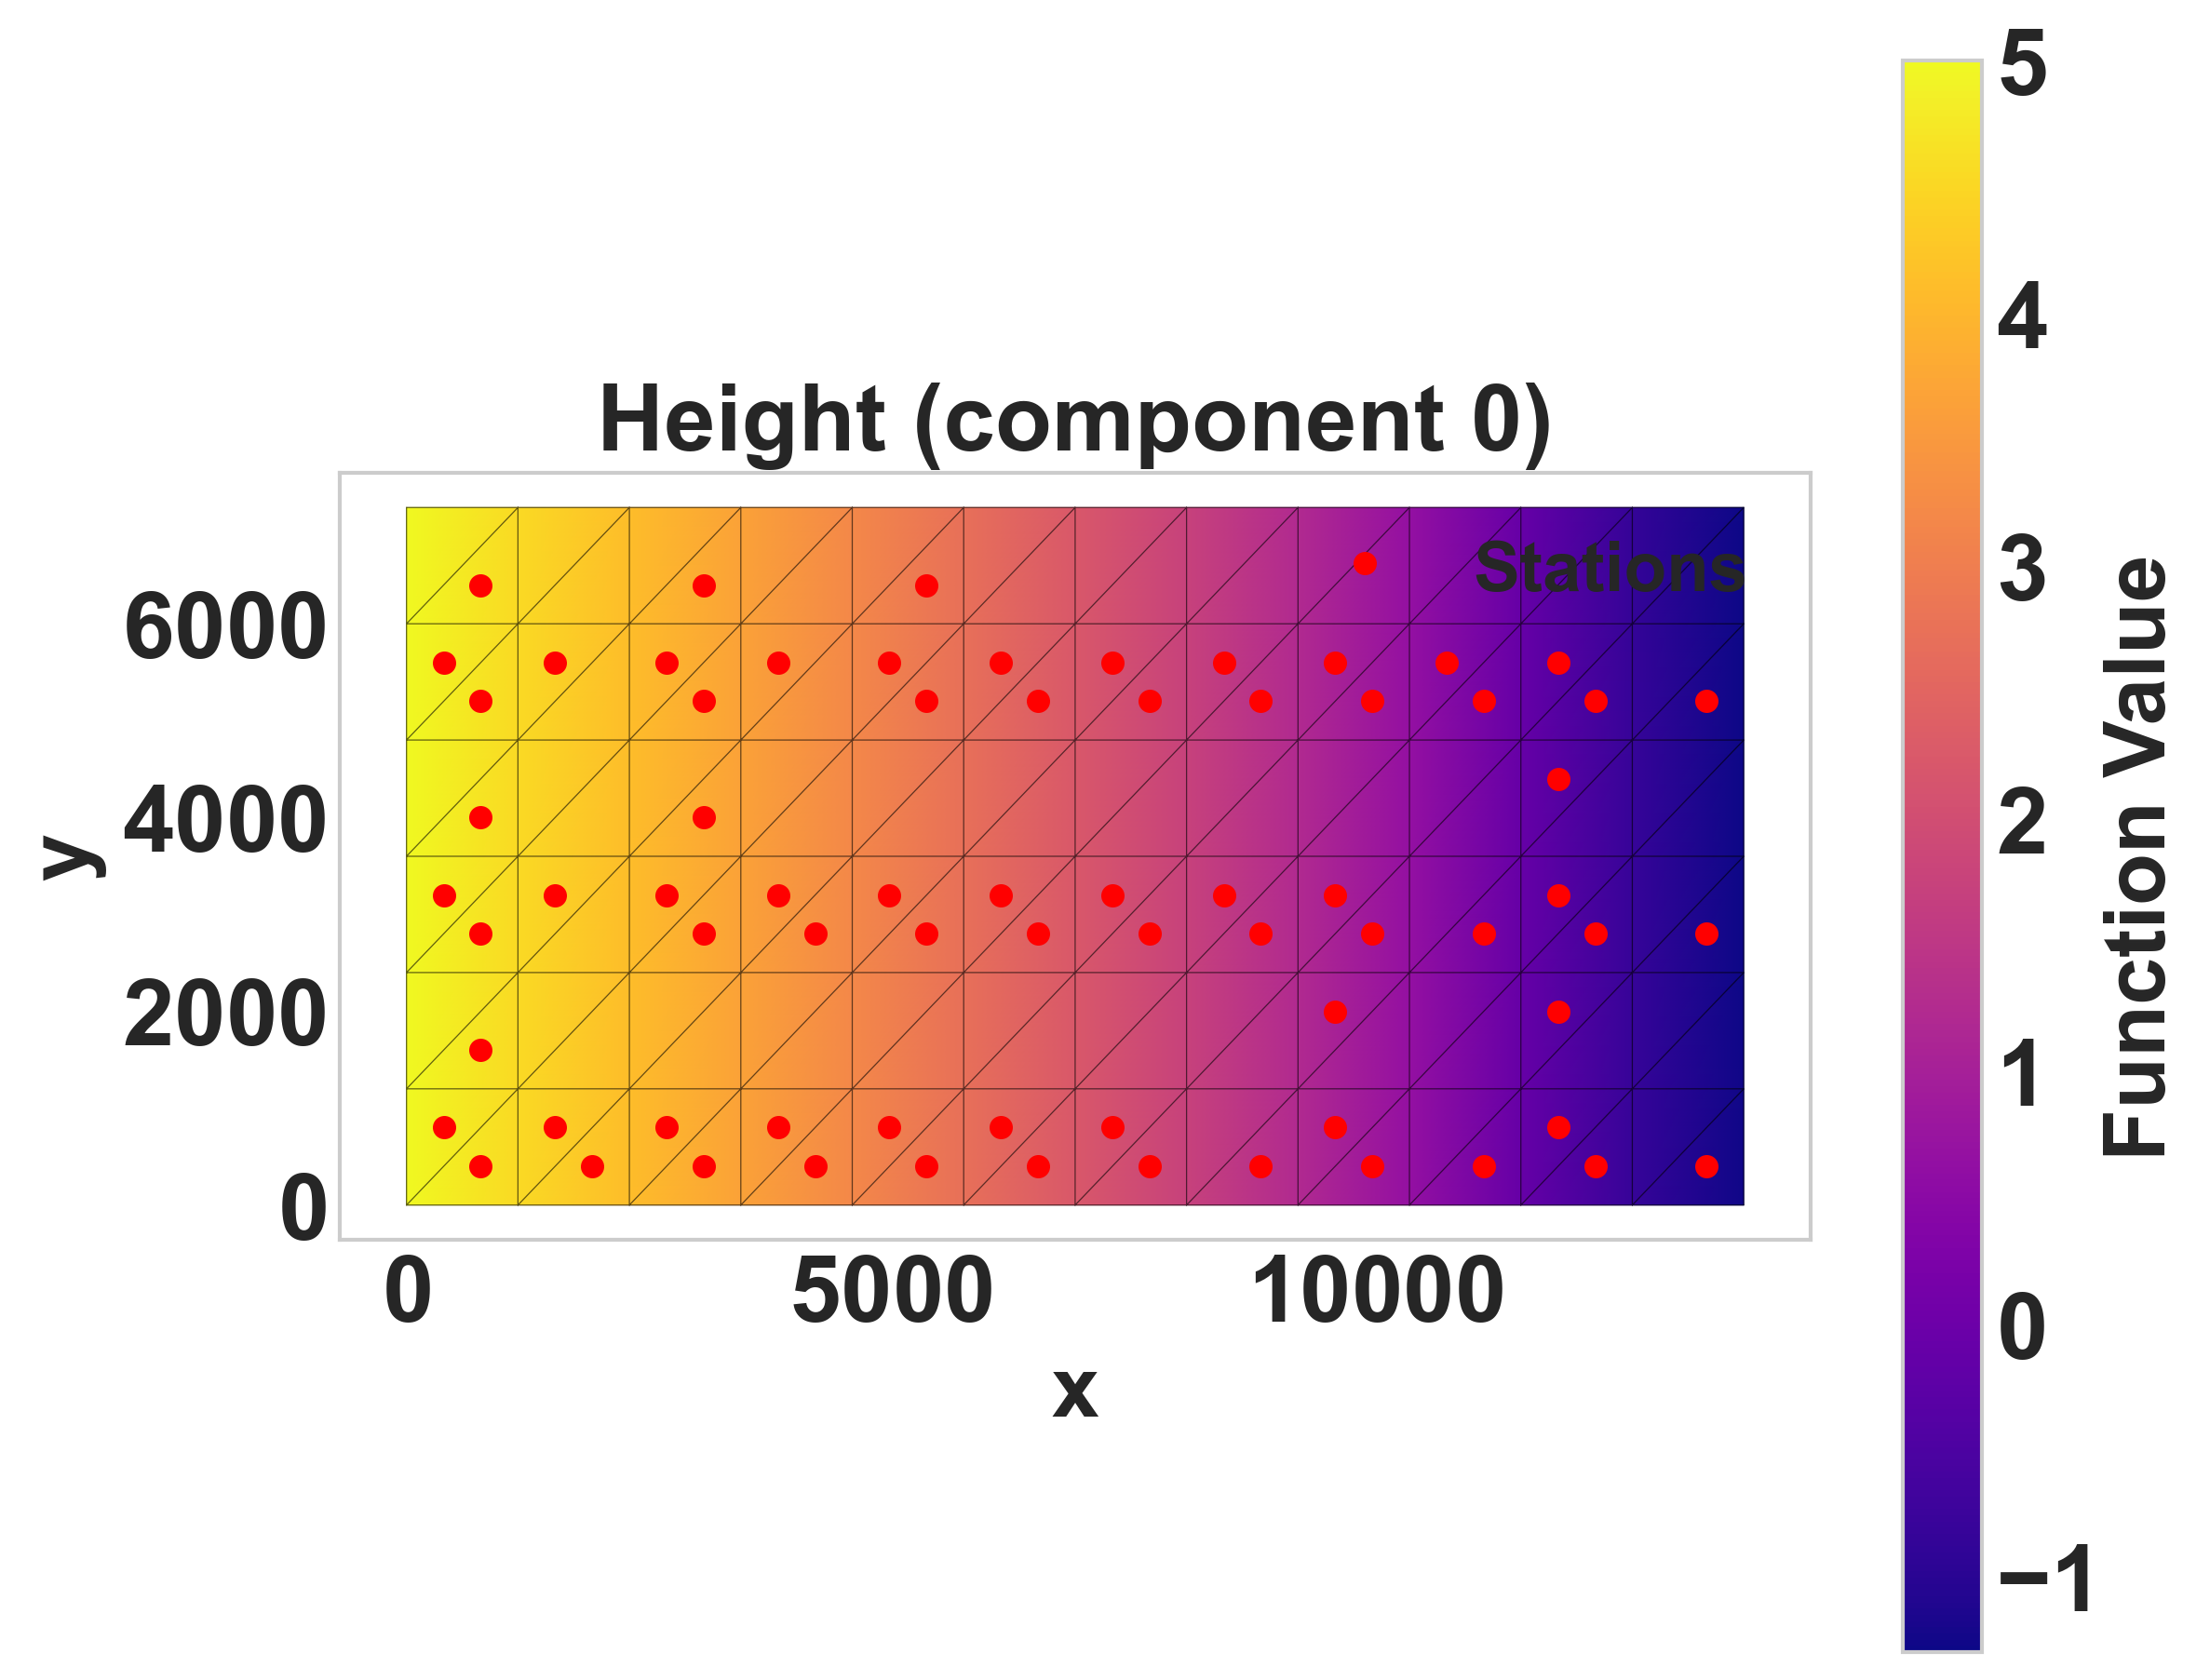

In [26]:
plot_mixed_function_matplotlib(prob.mesh,
                    true_signal.V,
                    true_signal.u,
                    component=0,
                    title="Height",
                    stations=stations,
                    cmap='plasma',
                    style='modern'
                    )

In [37]:
true_signal.saved_states[0].shape, bayes_analysis.shape

((1296,), (1009, 72, 3))

AttributeError: 'numpy.ndarray' object has no attribute 'x'

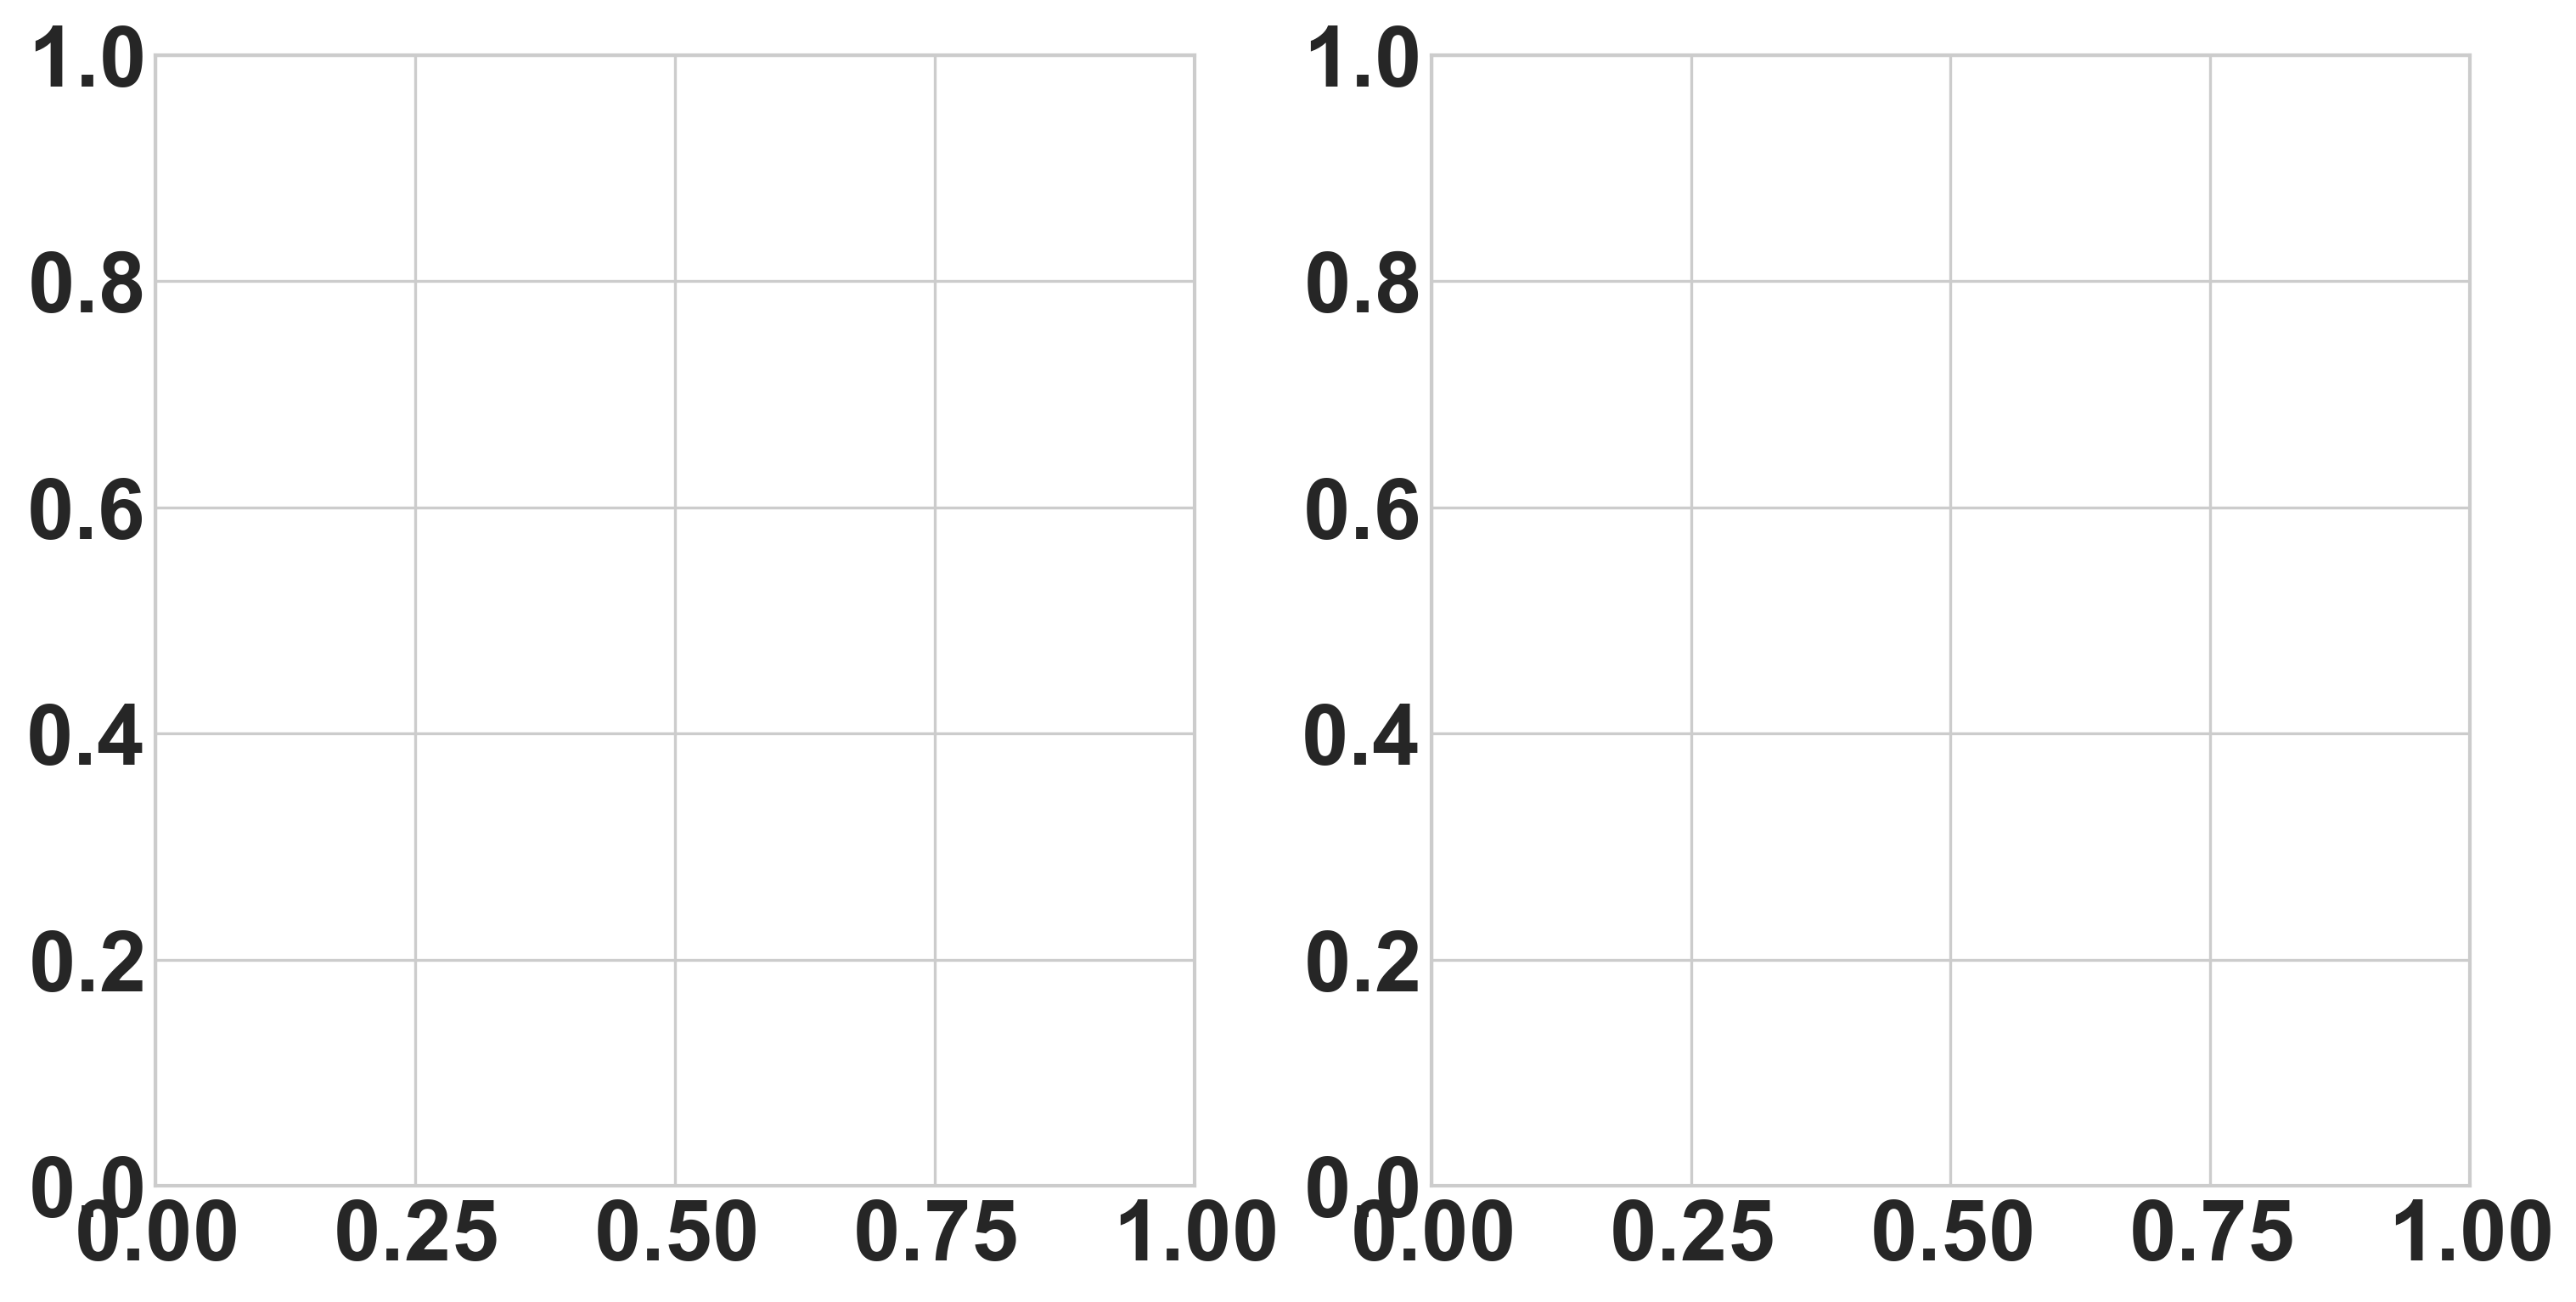

In [38]:
u_list = [true_signal.u.x.array[:], true_signal.u.x.array[:]]  # Use the x.array[:] for both true and predicted states
plot_comparison_matplotlib(prob.mesh, true_signal.V, u_list, component=0, titles=None, stations=None, cmap='viridis')